In [1]:
import pandas as pd
df=pd.read_excel("Saurabh_Test_Data.xlsx")
df_1=df.drop(["Active Stage","Record Status (Service Request) (Service Request)"],axis="columns")
df_1.head


<bound method NDFrame.head of       Owning Subsidiary (Marketing Project) (Marketing Project)    Task ID  \
0                                              Australia          ST789891   
1                                              Australia          ST789922   
2                                              Australia          ST791779   
3                                              Australia          ST791834   
4                                              Australia          ST791971   
...                                                  ...               ...   
43949                                            Denmark         ST1401881   
43950                                            Denmark         ST1401873   
43951                                              Spain         ST1401388   
43952                                              WE HQ         ST1401043   
43953                                              WE HQ         ST1400563   

             Service Type Audienc

In [2]:
# type(df_1["Created On"])
df_1["Created On"]=pd.to_datetime(df_1["Created On"],errors = 'coerce')


In [3]:
df_1["Year"]=df_1["Created On"].dt.year
df_1["Month"]=df_1["Created On"].dt.month
df_1["YearMonth"]=df_1["Created On"].dt.to_period('M').astype(str)
df_1.head()

,Owning Subsidiary (Marketing Project) (Marketing Project),Task ID,Service Type,Audience (Marketing Project) (Marketing Project),Created On,Service Task Type,Platform,Service Line (Service Type) (MASH Service),Year,Month,YearMonth
0,Australia,ST789891,Targeted List Pull,Commercial,2023-01-15 18:33:43,Campaign Counts,Marketo,Lead Acquisition & Engagement,2023,1,2023-01
1,Australia,ST789922,Targeted List Pull,Commercial,2023-01-15 20:34:04,Campaign Counts,Marketo,Lead Acquisition & Engagement,2023,1,2023-01
2,Australia,ST791779,Targeted List Pull,Commercial,2023-01-17 18:04:34,Campaign Counts,Marketo,Lead Acquisition & Engagement,2023,1,2023-01
3,Australia,ST791834,Targeted List Pull,Commercial,2023-01-17 18:46:22,Campaign Counts,Marketo,Lead Acquisition & Engagement,2023,1,2023-01
4,Australia,ST791971,Targeted List Pull,Commercial,2023-01-17 23:34:41,Campaign Counts,Marketo,Lead Acquisition & Engagement,2023,1,2023-01


In [4]:
Monthly_Count=df_1.groupby(["Owning Subsidiary (Marketing Project) (Marketing Project)","Service Type",
                            "Audience (Marketing Project) (Marketing Project)","Service Task Type","Platform",
                            "Service Line (Service Type) (MASH Service)","YearMonth"]).agg(TaskCount=('Task ID','count')).reset_index()
Monthly_Count.head()

,Owning Subsidiary (Marketing Project) (Marketing Project),Service Type,Audience (Marketing Project) (Marketing Project),Service Task Type,Platform,Service Line (Service Type) (MASH Service),YearMonth,TaskCount
0,ANZ HQ,Marketing Contact Management,Commercial,Lead upload,Marketo,Lead Acquisition & Engagement,2024-02,3
1,ANZ HQ,Marketing Contact Management,Commercial,PELN for Contact Management,Marketo,Lead Acquisition & Engagement,2024-02,2
2,ANZ HQ,Targeted List Pull,Commercial,List Pull Setup,UCMP,Lead Acquisition & Engagement,2024-02,3
3,ANZ HQ,Targeted List Pull,Commercial,List Pull Setup,UCMP,Lead Acquisition & Engagement,2024-04,1
4,ANZ HQ,Targeted List Pull,Commercial,List Pull Setup,UCMP,Lead Acquisition & Engagement,2024-09,6


In [5]:
Monthly_Count["Year"]= pd.to_datetime(Monthly_Count["YearMonth"]).dt.year
Monthly_Count["Month"]= pd.to_datetime(Monthly_Count["YearMonth"]).dt.month
Monthly_Count



,Owning Subsidiary (Marketing Project) (Marketing Project),Service Type,Audience (Marketing Project) (Marketing Project),Service Task Type,Platform,Service Line (Service Type) (MASH Service),YearMonth,TaskCount,Year,Month
0,ANZ HQ,Marketing Contact Management,Commercial,Lead upload,Marketo,Lead Acquisition & Engagement,2024-02,3,2024,2
1,ANZ HQ,Marketing Contact Management,Commercial,PELN for Contact Management,Marketo,Lead Acquisition & Engagement,2024-02,2,2024,2
2,ANZ HQ,Targeted List Pull,Commercial,List Pull Setup,UCMP,Lead Acquisition & Engagement,2024-02,3,2024,2
3,ANZ HQ,Targeted List Pull,Commercial,List Pull Setup,UCMP,Lead Acquisition & Engagement,2024-04,1,2024,4
4,ANZ HQ,Targeted List Pull,Commercial,List Pull Setup,UCMP,Lead Acquisition & Engagement,2024-09,6,2024,9
...,...,...,...,...,...,...,...,...,...,...
4442,WE HQ,Targeted List Pull,Partner,List Pull Setup,UCMP,Lead Acquisition & Engagement,2024-02,1,2024,2
4443,WE HQ,Targeted List Pull,Partner,List Pull Setup,UCMP,Lead Acquisition & Engagement,2024-04,2,2024,4
4444,WE HQ,Targeted List Pull,Partner,List Pull Setup,UCMP,Lead Acquisition & Engagement,2024-05,2,2024,5
4445,WE HQ,Targeted List Pull,Partner,List Pull Setup,UCMP,Lead Acquisition & Engagement,2024-08,1,2024,8


In [6]:
X=Monthly_Count.drop(columns=["YearMonth","TaskCount"])
Y=Monthly_Count["TaskCount"]

OneHotEnCoding


In [7]:
New_Var = ["Owning Subsidiary (Marketing Project) (Marketing Project)", 
           "Service Type", "Audience (Marketing Project) (Marketing Project)",	
           "Service Task Type","Platform","Service Line (Service Type) (MASH Service)",
           "Year","Month"]

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

pipeline = Pipeline(steps=[
    ('preprosessor',ColumnTransformer(
        transformers=[
            ("Trans",OneHotEncoder(handle_unknown='ignore'),New_Var)
          ])
    ),
    ('regressor',LinearRegression())
])

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(X,Y, test_size=0.2)
pipeline.fit(x_train,y_train)


Pipeline(steps=[('preprosessor',
                 ColumnTransformer(transformers=[('Trans',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Owning Subsidiary '
                                                   '(Marketing Project) '
                                                   '(Marketing Project)',
                                                   'Service Type',
                                                   'Audience (Marketing '
                                                   'Project) (Marketing '
                                                   'Project)',
                                                   'Service Task Type',
                                                   'Platform',
                                                   'Service Line (Service '
                                                   'Type) (MASH Service)',
                                                   'Year', 'Month'])])),
                ('regressor', LinearRegression())])

In [10]:
pipeline.score(x_test,y_test)

0.4006029712808318

In [11]:
import matplotlib.pyplot as pt
filteryear = df_1[df_1['Year'].isin([2022,2023,2024])]
MonthlyGroupCounts = filteryear.groupby(['Year','Month'])['Task ID'].count().reset_index()


In [12]:
Pivot = MonthlyGroupCounts.pivot(index = 'Month', columns = 'Year', values = 'Task ID')


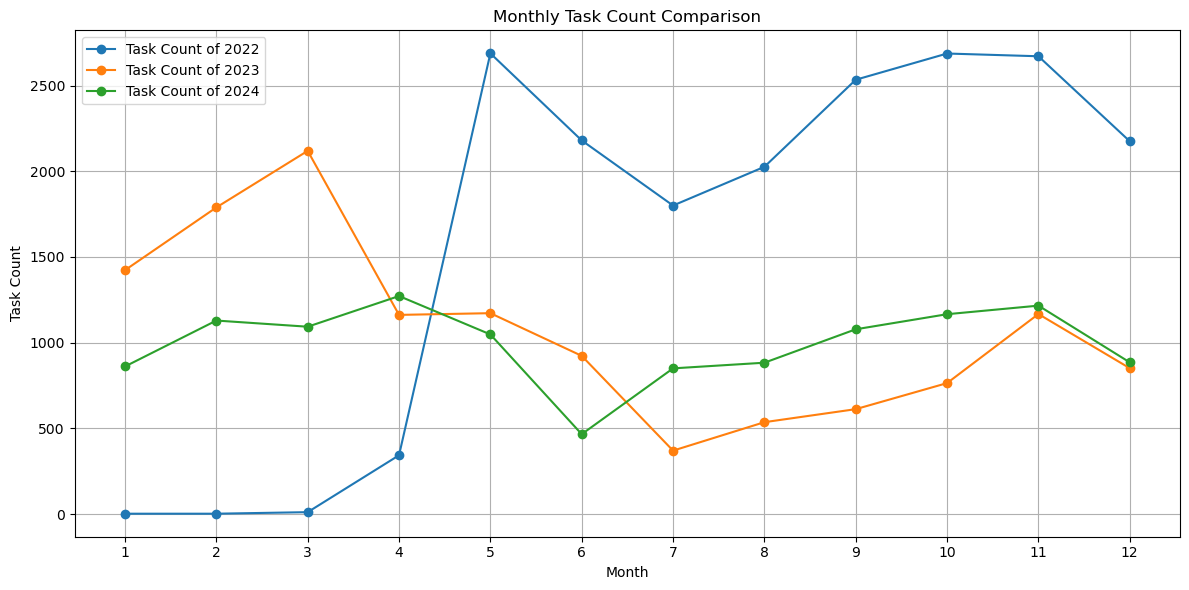

In [13]:
pt.figure(figsize=(12,6))
for x in [2022,2023,2024]:
    if x in Pivot.columns:
        pt.plot(Pivot.index, Pivot[x], label = f"Task Count of {x}", marker = 'o')
pt.title('Monthly Task Count Comparison')
pt.xlabel('Month')
pt.ylabel('Task Count')
pt.xticks(range(1,13))
pt.grid(True)
pt.legend()
pt.tight_layout()
pt.show()


In [14]:
latestyear = df_1['Year'].max()
latestyear_new = df_1[df_1['Year']==latestyear].copy()
Combination = (latestyear_new.groupby
               (["Owning Subsidiary (Marketing Project) (Marketing Project)", 
           "Service Type", "Audience (Marketing Project) (Marketing Project)",	
           "Service Task Type","Platform","Service Line (Service Type) (MASH Service)",
           "Year","Month"]
               ).size().reset_index().rename(columns = {0:'Count'}).sort_values(by='Count',ascending = False).head(10)
              )

In [15]:
Forecast_Row=[]
for Month in range(1,13):
    for _,row in Combination.iterrows():
        Forecast_Row.append
        (
         {
             **row.drop('Count'),
             'Year':  latestyear + 1,
             'Month': Month,
             
         }   
        )

Forecast_df = pd.DataFrame(Forecast_Row)
Forecasted_tasks = pipeline.predict(Forecast_df)
Forecast_df['Predicted TaskCount'] = Forecasted_tasks

Monthly_Forecast = Forecast_df.groupby(['Year', 'Month'])['Predicted TaskCount'].sum().reset_index()
Monthly_Foreacast

TypeError: 'NoneType' object is not iterable

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(Monthly_Forecast['Year'].astype(str) + '-' + Monthly_Forecast['Month'].astype(str)), 
         Monthly_Forecast['Predicted TaskCount'], marker='o')
plt.title("Forecasted Monthly Task Counts for 2025")
plt.xlabel("Month")
plt.ylabel("Predicted Tasks")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
forecast_rows = []
for month in range(1, 13):
    for _, row in top_combinations.iterrows():
        forecast_rows.append({
            **row.drop('Count'),
            'Year': latest_year + 1,
            'Month': month
        })

forecast_df = pd.DataFrame(forecast_rows)

forecasted_tasks = pipeline.predict(forecast_df)
forecast_df['Predicted TaskCount'] = forecasted_tasks

Monthly_Forecast = forecast_df.groupby(['Year', 'Month'])['Predicted TaskCount'].sum().reset_index()